## Estimate WM fractions (0-1) in the top 1000m of the Arctic Ocean using T, S, DO observations

In [58]:
# Load and prepare data

import pandas as pd
import numpy as np
import xarray as xr

data_path = '/Users/ko389/Documents/GitHub/Arctic_water_masses/data_products/Arctic_T_S_DO_data.nc'
arctic = xr.open_dataset(data_path).to_dataframe()

def set_up_arctic_data(df):

    # rename & reorder columns
    df=df.rename(columns={'dissolved_oxygen':'oxygen','conservative_temperature':'conservative_temp'})
    column_order = ['conservative_temp', 'absolute_salinity', 'oxygen','latitude', 'longitude', 'depth', 'source','nprof', 'datetime']
    df = df [column_order]

    # remove labrador sea
    labrador_Sea = df[(df['latitude']<80)&(df['longitude']<-40)&(df['longitude']>-120)].index
    df = df.drop(labrador_Sea)

    # remove data with depth > 1000m
    df = df[df['depth']<1000]
    df = df.dropna(subset=['conservative_temp','absolute_salinity','oxygen'])
    
    return df

arctic = set_up_arctic_data(arctic)

# Make a copy of data and add mass column
df = arctic.copy()  
df["mass"] = 1.0

/Users/ko389/miniconda3/envs/hydro_env_local/lib/python3.12/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


In [26]:
# Subsample 10% of the data for faster sensitivity tests
df_sampled = df.sample(frac=0.05, random_state=42)

In [32]:
0.9*24

21.6

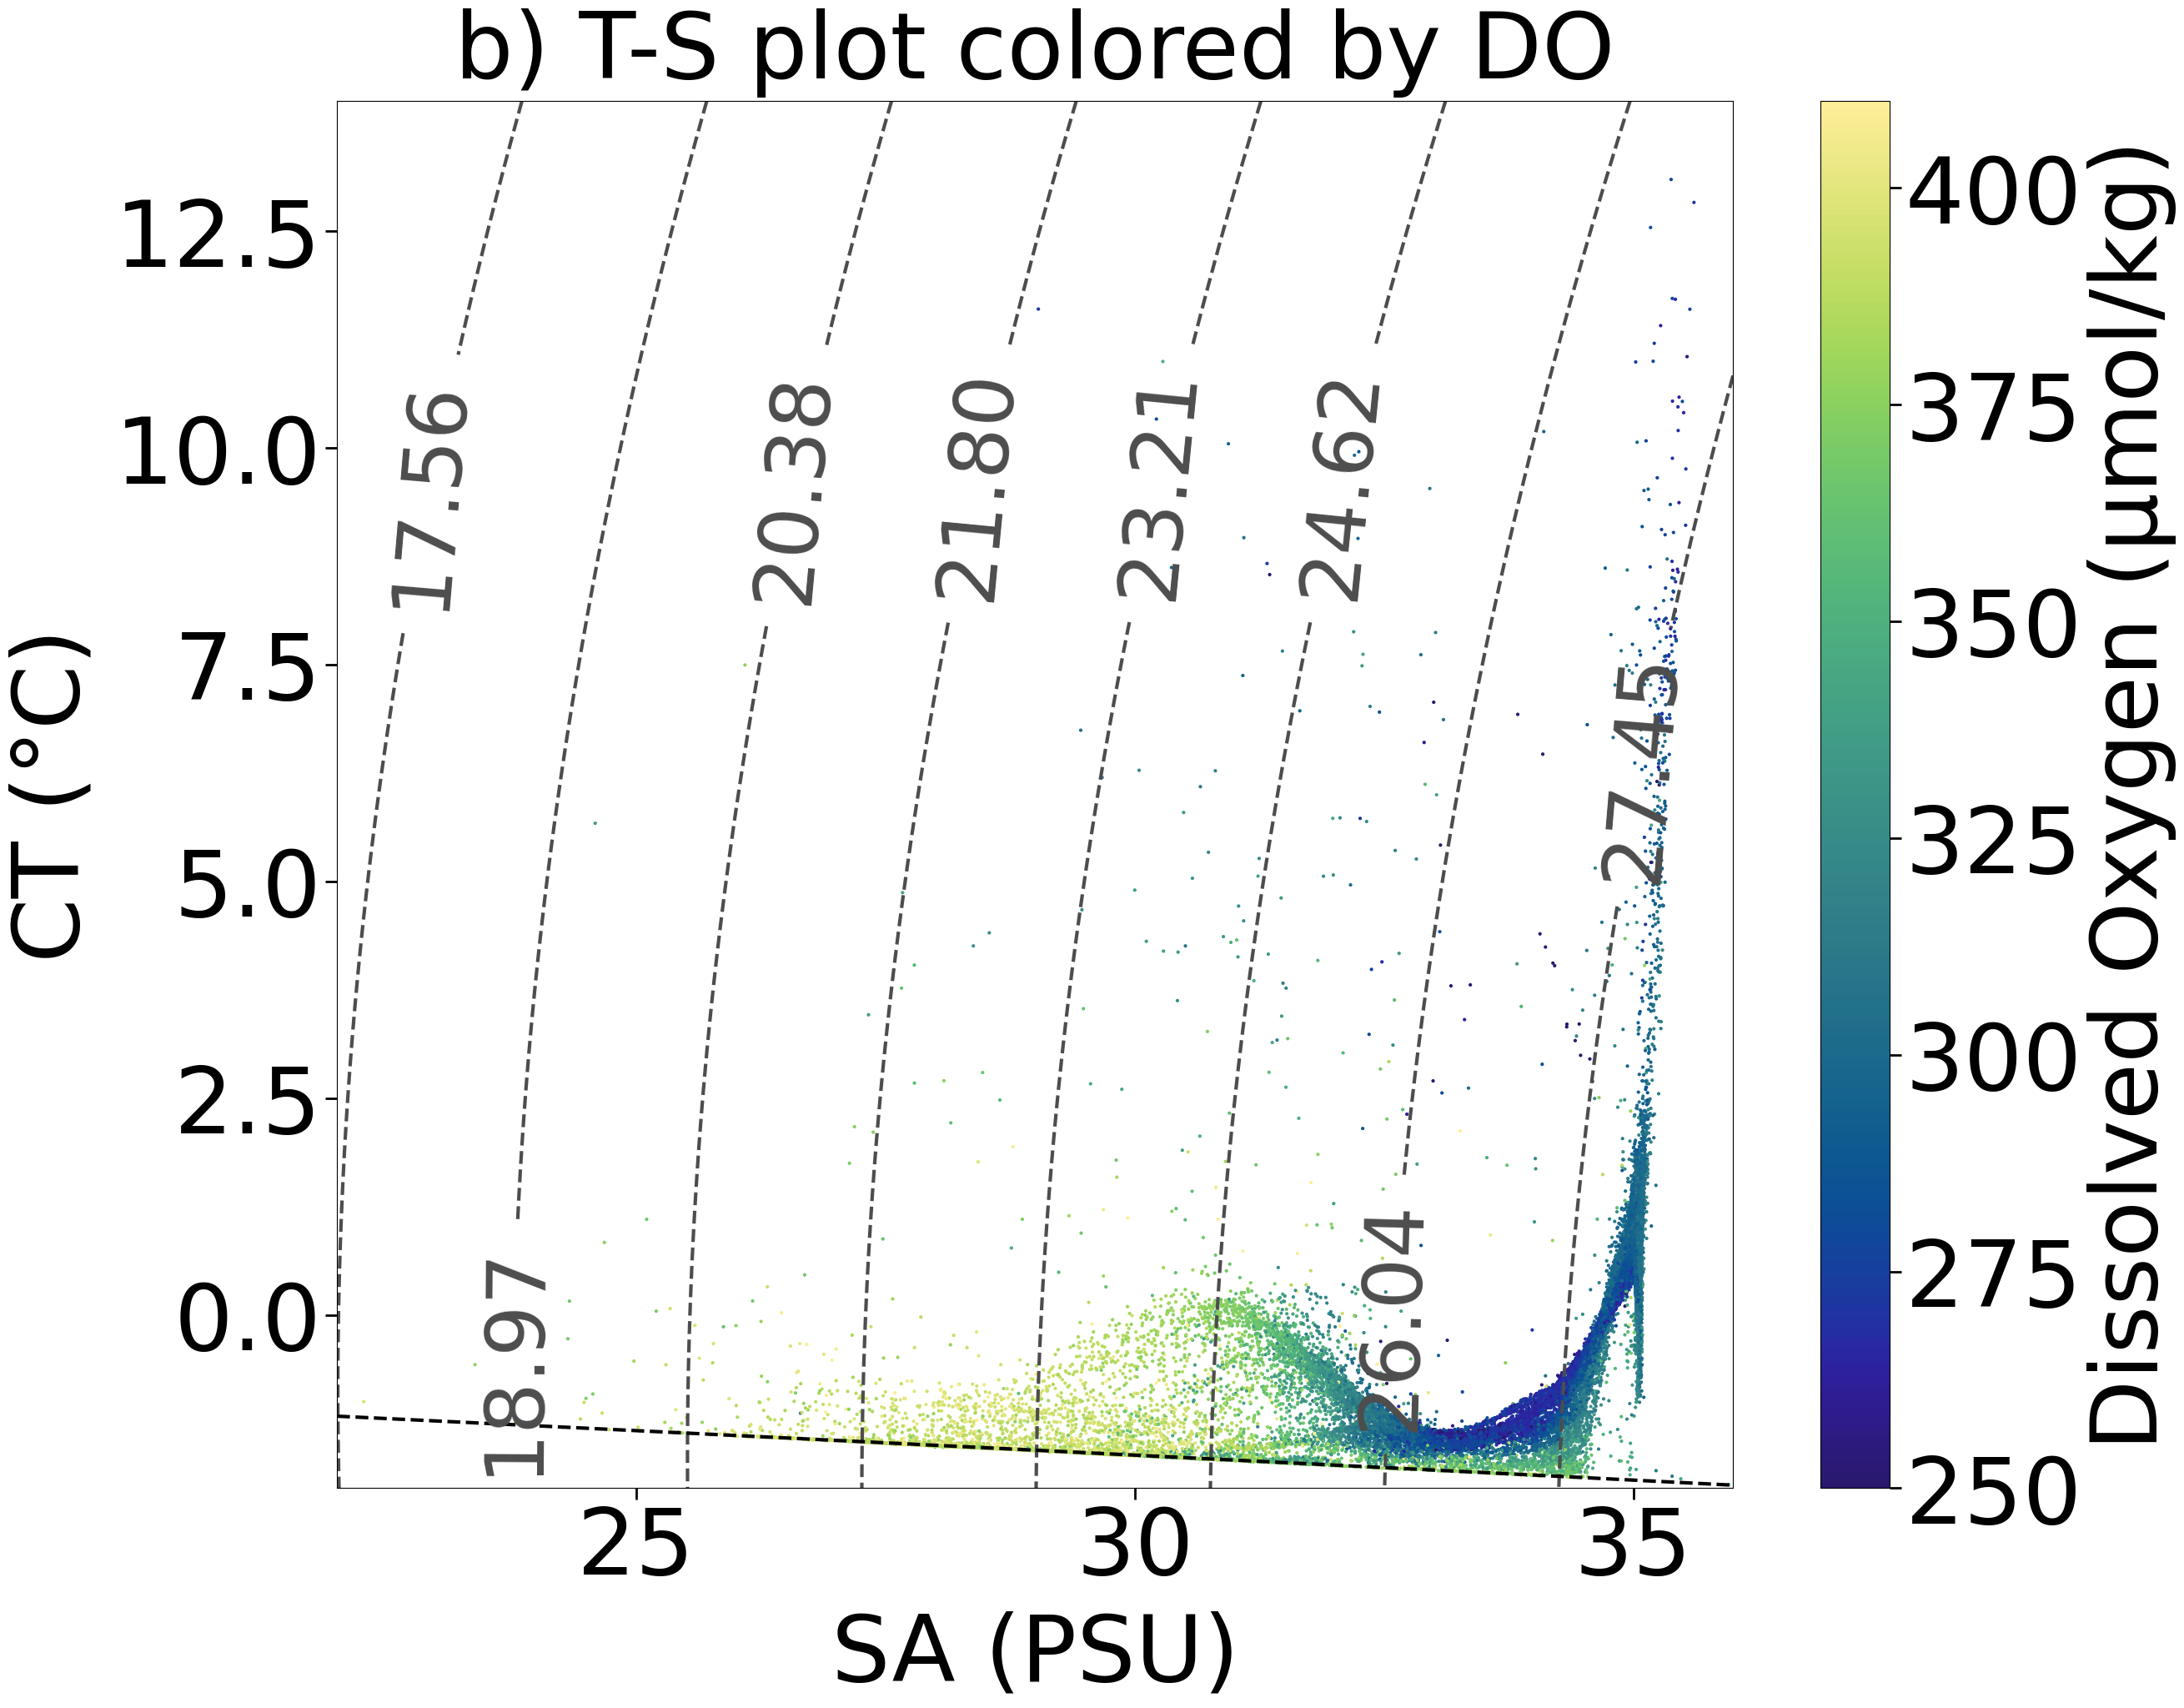

In [33]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.path as mpath
from matplotlib.colors import LogNorm
import seaborn as sn
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean.cm as cmo
import pandas as pd
import gsw
import matplotlib.patches as patches

def create_TS_bivariate_histogram(data):
    
    fig, ax = plt.subplots(1, 1, figsize=(27, 21.6))  # Bigger figure size


    # Scatter plot

    sc = ax.scatter(data['absolute_salinity'], data['conservative_temp'], c=data['oxygen'], s=4,cmap=cmo.haline, vmin=250, vmax=410)
    cbar = plt.colorbar(sc)
    # Add colorbar
    cbar.set_label('Dissolved Oxygen (\u00b5mol/kg)', fontsize=80)
    cbar.ax.tick_params(labelsize=80, width=2, length=10)

    # Sigma0 density contours
    SA, CT = np.meshgrid(np.linspace(22, 36, 400), np.linspace(-2, 14, 400))
    sigma0 = gsw.sigma0(SA, CT)
    levels = np.linspace(np.min(sigma0), np.max(sigma0), 10)
    contour = ax.contour(
        SA, CT, sigma0, levels=levels, 
        linestyles='--', colors='#4d4d4d', linewidths=3
    )
    ax.clabel(contour, inline=True, fontsize=70)

    # Freezing line
    CT_freezing = gsw.CT_freezing(np.linspace(22, 36, 400), 0, 0)
    ax.plot(
        np.linspace(22, 36, 400), CT_freezing, 
        linestyle='--', color='black', linewidth=3, label="Freezing Line"
    )

    # Labels and axis limits
    ax.set_xlabel('SA (PSU)', fontsize=80, labelpad=15)
    ax.set_ylabel('CT (\u00b0C)', fontsize=80, labelpad=15)
    ax.set_xlim([22, 36])
    ax.set_ylim([-2, 14])
    ax.tick_params(axis='both', which='major', labelsize=80, width=2, length=10)

    # Add title
    ax.set_title('b) T-S plot colored by DO', fontsize=80, pad=20)
    
    # Colorbar
    #cbar = plt.colorbar(hist[3], ax=ax)
    #cbar.set_label('Number of T, S data points', fontsize=70)
    #cbar.ax.tick_params(labelsize=60, width=2, length=10)

    # Remove grid
    ax.grid(False)

    # Show plot
    plt.show()
    #fig.savefig('/Users/ko389/Documents/T_S_distribution', dpi=300, bbox_inches='tight', transparent=True)

create_TS_bivariate_histogram(df_sampled)

Run a baseline OMP on sampled data

In [ ]:
import pandas as pd

# Define endmembers (SWTs) with updated values
endmemberdf = pd.DataFrame({
    "endmember_name": ["ASW", "MsPW", "sPW", "wPW", "NCW", "AW", "BW"],
    "conservative_temp": [-1.45, 0.5, 6, -1.5, 8, 0.0, -1.8],
    "absolute_salinity": [27, 31, 31.2, 33.2, 35.4, 35.05, 34.45],
    "oxygen": [390.53, 354.21, 314, 280.84, 287.82, 298, 370],
    "mass": [1, 1, 1, 1, 1, 1, 1]
})

endmemberdf



,endmember_name,conservative_temp,absolute_salinity,oxygen,mass
0,ASW,-1.45,27.00,390.53,1
1,MsPW,0.50,31.00,354.21,1
2,sPW,6.00,31.20,314.00,1
3,wPW,-1.50,33.20,280.84,1
4,NCW,8.00,35.40,287.82,1
5,AW,0.00,35.05,298.00,1
6,BW,-1.80,34.45,370.00,1


In [ ]:
# Settings for OMP (replace with your own if different)
import pyompa
from pyompa import (
    plot_ompasoln_endmember_fractions,
    plot_ompasoln_residuals,
    plot_ompasoln_endmember_usagepenalties
)
convertedparamgroups = [
    pyompa.ConvertedParamGroup(
        groupname="phosphate_remin",
        conversion_ratios=[{"oxygen": -170, "phosphate": 1.0}],
        always_positive=False
    )
]
paramweightings = {
    "conservative_temp": 24,
    "absolute_salinity": 24,
    "oxygen": 7, 
    "mass": 24
}
hardmasscons_settings = {
    "param_names": ["conservative_temp", "absolute_salinity","oxygen","mass"], 
    "param_weightings": paramweightings,
    "convertedparam_groups": convertedparamgroups,
    "sumtooneconstraint": True,
    "standardize_by_watertypes": True
}

In [ ]:
# Define OMP function

def run_omp(data, endmembers):
    chunk_size = 10000
    num_chunks = len(data) // chunk_size + 1
    column_titles = list(endmembers["endmember_name"].values)

    all_chunks = []  # store results here

    for i in range(num_chunks):
        start_idx = i * chunk_size
        end_idx = min((i + 1) * chunk_size, len(data))
        chunk_df = data.iloc[start_idx:end_idx]

        ompasol = pyompa.OMPAProblem(
            obs_df=chunk_df.dropna(),
            **hardmasscons_settings
        ).solve(
            endmembers,
            endmember_name_column="endmember_name"
        )

        # Append chunk results to list
        all_chunks.append(
            pd.DataFrame(ompasol.endmember_fractions, columns=column_titles)
        )

    # Concatenate all at once for speed
    all_wm_fractions = pd.concat(all_chunks, ignore_index=True)

    return all_wm_fractions


In [ ]:
# Run baseline OMP

baseline_fractions = run_omp(df_sampled, endmemberdf)

Endmember-idx mapping is
 OrderedDict({'ASW': [0], 'MsPW': [1], 'sPW': [2], 'wPW': [3], 'NCW': [4], 'AW': [5], 'BW': [6]})
I'm assuming that the index encoding mass is: [3]
Std used for normalization: [ 3.96362929  2.98298748 43.38857678  1.        ]
Mean used for normalization: [  1.39285714  32.47142857 327.91428571   0.        ]
params to use: ['conservative_temp', 'absolute_salinity', 'oxygen', 'mass']
param weighting: [24 24  7 24]
effective weighting: [ 6.05505668  8.04562546  0.16133279 24.        ]
Matrix A:
Trying convertedvariable sign constraint: [1]
On example 0 to 10000 out of 10000
status: optimal
optimal value 3814409.6914513255
Original weighted sum squares: 3814409.6914513255
Post fix weighted sum squared: 3816338.340501546
Trying convertedvariable sign constraint: [-1]
On example 0 to 10000 out of 10000
status: optimal
optimal value 3851537.2252258207
Original weighted sum squares: 3851537.2252258207
Post fix weighted sum squared: 3851838.276116629
On example 0 to 100

Run 28 perturbed OMP on sampled data

In [54]:
values = {
    'ASW_T': -1.45, 
    'ASW_S': 27,
    'ASW_O': 390.53,
    'MsPW_T': 0.5, 
    'MsPW_S': 31,
    'MsPW_O': 354.21,
    'sPW_T': 6,
    'sPW_S': 31.2,
    'sPW_O': 314,
    'wPW_T': -1.5,
    'wPW_S': 33.2,
    'wPW_O': 280.84,
    'NCW_T': 8, 
    'NCW_S': 35.4,
    'NCW_O': 287.82,
    'AW_T': 0.0, 
    'AW_S': 35.05,
    'AW_O': 298,
    'BW_T': -1.8, 
    'BW_S': 34.45,
    'BW_O': 370
}
perturbation = 0.4

# Compute perturbation boxes
perturbation_boxes = {}
for wm in ['ASW','MsPW','sPW','wPW','NCW','AW','BW']:
    sa = values[f'{wm}_S']
    ct = values[f'{wm}_T']
    sa_min, sa_max = sa - perturbation, sa + perturbation
    ct_min, ct_max = ct - perturbation, ct + perturbation
    corners_sa = [sa_min, sa_min, sa_max, sa_max, sa_min]  # rectangle closed
    corners_ct = [ct_min, ct_max, ct_max, ct_min, ct_min]
    perturbation_boxes[wm] = {
        'SA_min': sa_min, 'SA_max': sa_max,
        'CT_min': ct_min, 'CT_max': ct_max,
        'corners_sa': corners_sa,
        'corners_ct': corners_ct
    }

# Shift some SWTs up to freezling line - 0.4 perturbation version
perturbation_boxes['ASW']['CT_min'] += 0.4
perturbation_boxes['ASW']['corners_ct'][0] += 0.4  # bottom-left
perturbation_boxes['ASW']['corners_ct'][4] += 0.4  # bottom-right (closing point)
perturbation_boxes['BW']['CT_min'] += 0.4
perturbation_boxes['BW']['corners_ct'][0] += 0.4
perturbation_boxes['BW']['corners_ct'][4] += 0.4
perturbation_boxes['wPW']['CT_min'] += 0.1
perturbation_boxes['wPW']['corners_ct'][0] += 0.1
perturbation_boxes['wPW']['corners_ct'][4] += 0.1

# Shift some SWTs up to freezling line - 0.4 perturbation version
"""perturbation_boxes['ASW']['CT_min'] += 0.2
perturbation_boxes['ASW']['corners_ct'][0] += 0.2  # bottom-left
perturbation_boxes['ASW']['corners_ct'][4] += 0.2  # bottom-right (closing point)
perturbation_boxes['BW']['CT_min'] += 0.2
perturbation_boxes['BW']['corners_ct'][0] += 0.2
perturbation_boxes['BW']['corners_ct'][4] += 0.2"""



# Shift only the right SA edge leftward by 0.2 for AW and NCW
"""perturbation_boxes['AW']['SA_max'] -= 0.2
perturbation_boxes['AW']['corners_sa'][2] -= 0.2  # top-right
perturbation_boxes['AW']['corners_sa'][3] -= 0.2  # bottom-right
perturbation_boxes['NCW']['SA_max'] -= 0.2
perturbation_boxes['NCW']['corners_sa'][2] -= 0.2  # top-right
perturbation_boxes['NCW']['corners_sa'][3] -= 0.2  # bottom-right"""





"perturbation_boxes['AW']['SA_max'] -= 0.2\nperturbation_boxes['AW']['corners_sa'][2] -= 0.2  # top-right\nperturbation_boxes['AW']['corners_sa'][3] -= 0.2  # bottom-right\nperturbation_boxes['NCW']['SA_max'] -= 0.2\nperturbation_boxes['NCW']['corners_sa'][2] -= 0.2  # top-right\nperturbation_boxes['NCW']['corners_sa'][3] -= 0.2  # bottom-right"

In [55]:
# Each SWT has 4 perturbations: +ΔCT, -ΔCT, +ΔSA, -ΔSA
perturbation_tests = []

for wm, box in perturbation_boxes.items():
    sa_min, sa_max = box['SA_min'], box['SA_max']
    ct_min, ct_max = box['CT_min'], box['CT_max']
    
    # 4 corners / perturbations
    perturbation_tests.append({'wm': wm, 'SA': sa_min, 'CT': values[f'{wm}_T'], 'desc': '+SA'})
    perturbation_tests.append({'wm': wm, 'SA': sa_max, 'CT': values[f'{wm}_T'], 'desc': '-SA'})
    perturbation_tests.append({'wm': wm, 'SA': values[f'{wm}_S'], 'CT': ct_min, 'desc': '-CT'})
    perturbation_tests.append({'wm': wm, 'SA': values[f'{wm}_S'], 'CT': ct_max, 'desc': '+CT'})

In [ ]:
# Re-running OMP 28 times (7 SWTs * 4 perturbations each)
def run_perturbation(test):
    wm = test['wm']
    SA_new = test['SA']
    CT_new = test['CT']
    
    # Copy and perturb endmembers
    endmembers_perturbed = endmemberdf.copy()
    endmembers_perturbed.loc[endmembers_perturbed['endmember_name'] == wm, 'absolute_salinity'] = SA_new
    endmembers_perturbed.loc[endmembers_perturbed['endmember_name'] == wm, 'conservative_temp'] = CT_new
    
    # Run OMP with perturbed endmembers
    fractions = run_omp(df_sampled, endmembers_perturbed)
    
    # Return just the raw OMP output
    return {
        'wm': wm,
        'desc': test['desc'],
        'fractions': fractions   # <-- raw output, no % change
    }


In [ ]:
from concurrent.futures import ThreadPoolExecutor

with ThreadPoolExecutor(max_workers=4) as executor:
    sensitivity_results = list(executor.map(run_perturbation, perturbation_tests))

Endmember-idx mapping is
 OrderedDict({'ASW': [0], 'MsPW': [1], 'sPW': [2], 'wPW': [3], 'NCW': [4], 'AW': [5], 'BW': [6]})
Endmember-idx mapping is
 OrderedDict({'ASW': [0], 'MsPW': [1], 'sPW': [2], 'wPW': [3], 'NCW': [4], 'AW': [5], 'BW': [6]})
I'm assuming that the index encoding mass is: [3]
Std used for normalization: [ 3.96362929  3.10654072 43.38857678  1.        ]
Mean used for normalization: [  1.39285714  32.41428571 327.91428571   0.        ]
I'm assuming that the index encoding mass is: [3]
Std used for normalization: [ 3.96362929  2.86208798 43.38857678  1.        ]
Mean used for normalization: [  1.39285714  32.52857143 327.91428571   0.        ]
params to use: ['conservative_temp', 'absolute_salinity', 'oxygen', 'mass']
param weighting: [24 24  7 24]
effective weighting: [ 6.05505668  7.72563509  0.16133279 24.        ]
params to use: ['conservative_temp', 'absolute_salinity', 'oxygen', 'mass']
param weighting: [24 24  7 24]
effective weighting: [ 6.05505668  8.38548645  

In [ ]:
# Extract the results (4 perturbations for each SWT)

# ASW
asw_1 = next(item['fractions'] 
                      for item in sensitivity_results 
                      if item['wm'] == 'ASW' and item['desc'] == '+SA')
asw_2 = next(item['fractions'] 
                      for item in sensitivity_results 
                      if item['wm'] == 'ASW' and item['desc'] == '-SA')
asw_3 = next(item['fractions'] 
                      for item in sensitivity_results 
                      if item['wm'] == 'ASW' and item['desc'] == '+CT')
asw_4 = next(item['fractions'] 
                      for item in sensitivity_results
                      if item['wm'] == 'ASW' and item['desc'] == '-CT')
asw_1_diff = asw_1 - baseline_fractions
asw_2_diff = asw_2 - baseline_fractions
asw_3_diff = asw_3 - baseline_fractions
asw_4_diff = asw_4 - baseline_fractions
asw_mean_diff = (asw_1_diff.abs() + asw_2_diff.abs() + asw_3_diff.abs() + asw_4_diff.abs()) / 4

#MsPW
mspw_1 = next(item['fractions'] 
                      for item in sensitivity_results
                        if item['wm'] == 'MsPW' and item['desc'] == '+SA')
mspw_2 = next(item['fractions'] 
                      for item in sensitivity_results
                        if item['wm'] == 'MsPW' and item['desc'] == '-SA')
mspw_3 = next(item['fractions'] 
                      for item in sensitivity_results
                        if item['wm'] == 'MsPW' and item['desc'] == '+CT')
mspw_4 = next(item['fractions'] 
                      for item in sensitivity_results
                        if item['wm'] == 'MsPW' and item['desc'] == '-CT')
mspw_1_diff = mspw_1 - baseline_fractions
mspw_2_diff = mspw_2 - baseline_fractions
mspw_3_diff = mspw_3 - baseline_fractions
mspw_4_diff = mspw_4 - baseline_fractions
mspw_mean_diff = (mspw_1_diff.abs() + mspw_2_diff.abs() + mspw_3_diff.abs() + mspw_4_diff.abs()) / 4

#sPW
spw_1 = next(item['fractions'] 
                      for item in sensitivity_results
                        if item['wm'] == 'sPW' and item['desc'] == '+SA')
spw_2 = next(item['fractions'] 
                      for item in sensitivity_results
                        if item['wm'] == 'sPW' and item['desc'] == '-SA')
spw_3 = next(item['fractions'] 
                      for item in sensitivity_results
                        if item['wm'] == 'sPW' and item['desc'] == '+CT')
spw_4 = next(item['fractions'] 
                      for item in sensitivity_results
                        if item['wm'] == 'sPW' and item['desc'] == '-CT')
spw_1_diff = spw_1 - baseline_fractions
spw_2_diff = spw_2 - baseline_fractions
spw_3_diff = spw_3 - baseline_fractions
spw_4_diff = spw_4 - baseline_fractions
spw_mean_diff = (spw_1_diff.abs() + spw_2_diff.abs() + spw_3_diff.abs() + spw_4_diff.abs()) / 4

#wPW
wpw_1 = next(item['fractions'] 
                      for item in sensitivity_results
                        if item['wm'] == 'wPW' and item['desc'] == '+SA')
wpw_2 = next(item['fractions'] 
                      for item in sensitivity_results
                        if item['wm'] == 'wPW' and item['desc'] == '-SA')
wpw_3 = next(item['fractions'] 
                      for item in sensitivity_results
                        if item['wm'] == 'wPW' and item['desc'] == '+CT')
wpw_4 = next(item['fractions'] 
                      for item in sensitivity_results
                        if item['wm'] == 'wPW' and item['desc'] == '-CT')
wpw_1_diff = wpw_1 - baseline_fractions
wpw_2_diff = wpw_2 - baseline_fractions
wpw_3_diff = wpw_3 - baseline_fractions
wpw_4_diff = wpw_4 - baseline_fractions
wpw_mean_diff = (wpw_1_diff.abs() + wpw_2_diff.abs() + wpw_3_diff.abs() + wpw_4_diff.abs()) / 4

#NCW
ncw_1 = next(item['fractions'] 
                      for item in sensitivity_results
                        if item['wm'] == 'NCW' and item['desc'] == '+SA')
ncw_2 = next(item['fractions'] 
                      for item in sensitivity_results
                        if item['wm'] == 'NCW' and item['desc'] == '-SA')
ncw_3 = next(item['fractions'] 
                      for item in sensitivity_results
                        if item['wm'] == 'NCW' and item['desc'] == '+CT')
ncw_4 = next(item['fractions'] 
                      for item in sensitivity_results
                        if item['wm'] == 'NCW' and item['desc'] == '-CT')
ncw_1_diff = ncw_1 - baseline_fractions
ncw_2_diff = ncw_2 - baseline_fractions
ncw_3_diff = ncw_3 - baseline_fractions
ncw_4_diff = ncw_4 - baseline_fractions
ncw_mean_diff = (ncw_1_diff.abs() + ncw_2_diff.abs() + ncw_3_diff.abs() + ncw_4_diff.abs()) / 4     

#AW
aw_1 = next(item['fractions'] 
                      for item in sensitivity_results
                        if item['wm'] == 'AW' and item['desc'] == '+SA')
aw_2 = next(item['fractions'] 
                      for item in sensitivity_results
                        if item['wm'] == 'AW' and item['desc'] == '-SA')
aw_3 = next(item['fractions'] 
                      for item in sensitivity_results
                        if item['wm'] == 'AW' and item['desc'] == '+CT')
aw_4 = next(item['fractions'] 
                      for item in sensitivity_results
                        if item['wm'] == 'AW' and item['desc'] == '-CT')
aw_1_diff = aw_1 - baseline_fractions
aw_2_diff = aw_2 - baseline_fractions
aw_3_diff = aw_3 - baseline_fractions
aw_4_diff = aw_4 - baseline_fractions
aw_mean_diff = (aw_1_diff.abs()  + aw_2_diff.abs() + aw_3_diff.abs() + aw_4_diff.abs()) / 4

#BW
bw_1 = next(item['fractions'] 
                      for item in sensitivity_results
                        if item['wm'] == 'BW' and item['desc'] == '+SA')
bw_2 = next(item['fractions'] 
                      for item in sensitivity_results
                        if item['wm'] == 'BW' and item['desc'] == '-SA')
bw_3 = next(item['fractions'] 
                      for item in sensitivity_results
                        if item['wm'] == 'BW' and item['desc'] == '+CT')
bw_4 = next(item['fractions'] 
                      for item in sensitivity_results
                        if item['wm'] == 'BW' and item['desc'] == '-CT')
bw_1_diff = bw_1 - baseline_fractions
bw_2_diff = bw_2 - baseline_fractions
bw_3_diff = bw_3 - baseline_fractions
bw_4_diff = bw_4 - baseline_fractions
bw_mean_diff = (bw_1_diff.abs() + bw_2_diff.abs() + bw_3_diff.abs() + bw_4_diff.abs()) / 4

In [ ]:
# Save the mean_diff dataframes
asw_mean_diff.to_csv('/Users/ko389/Documents/GitHub/Arctic_water_masses/data_products/asw_mean_diff_04.csv', index=False)
mspw_mean_diff.to_csv('/Users/ko389/Documents/GitHub/Arctic_water_masses/data_products/mspw_mean_diff_04.csv', index=False)
spw_mean_diff.to_csv('/Users/ko389/Documents/GitHub/Arctic_water_masses/data_products/spw_mean_diff_04.csv', index=False)
wpw_mean_diff.to_csv('/Users/ko389/Documents/GitHub/Arctic_water_masses/data_products/wpw_mean_diff_04.csv', index=False)
ncw_mean_diff.to_csv('/Users/ko389/Documents/GitHub/Arctic_water_masses/data_products/ncw_mean_diff_04.csv', index=False)
aw_mean_diff.to_csv('/Users/ko389/Documents/GitHub/Arctic_water_masses/data_products/aw_mean_diff_04.csv', index=False)
bw_mean_diff.to_csv('/Users/ko389/Documents/GitHub/Arctic_water_masses/data_products/bw_mean_diff_04.csv', index=False)

Look at the results

In [48]:
# Open the mean_diff dataframes
asw_mean_diff = pd.read_csv('/Users/ko389/Documents/GitHub/Arctic_water_masses/data_products/asw_mean_diff_04.csv')
mspw_mean_diff = pd.read_csv('/Users/ko389/Documents/GitHub/Arctic_water_masses/data_products/mspw_mean_diff_04.csv')
spw_mean_diff = pd.read_csv('/Users/ko389/Documents/GitHub/Arctic_water_masses/data_products/spw_mean_diff_04.csv')
wpw_mean_diff = pd.read_csv('/Users/ko389/Documents/GitHub/Arctic_water_masses/data_products/wpw_mean_diff_04.csv')
ncw_mean_diff = pd.read_csv('/Users/ko389/Documents/GitHub/Arctic_water_masses/data_products/ncw_mean_diff_04.csv')
aw_mean_diff = pd.read_csv('/Users/ko389/Documents/GitHub/Arctic_water_masses/data_products/aw_mean_diff_04.csv')
bw_mean_diff = pd.read_csv('/Users/ko389/Documents/GitHub/Arctic_water_masses/data_products/bw_mean_diff_04.csv')

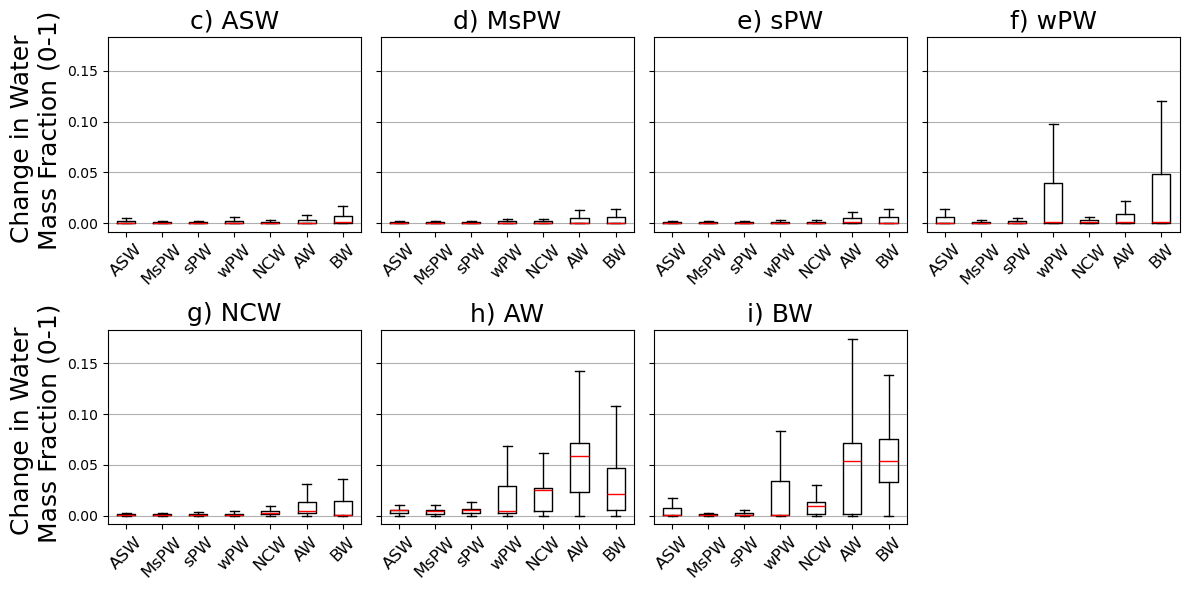

In [64]:
import matplotlib.pyplot as plt


# List of your 7 DataFrames
diff_dfs = [asw_mean_diff, mspw_mean_diff, spw_mean_diff, wpw_mean_diff, ncw_mean_diff, aw_mean_diff, bw_mean_diff]
titles = ['c) ASW', 'd) MsPW', 'e) sPW', 'f) wPW', 'g) NCW', 'h) AW', 'i) BW']

# Column labels (same for all)
columns = asw_mean_diff.columns.tolist()

# 4 rows, 2 columns
fig, axes = plt.subplots(2, 4, figsize=(12, 6), sharey=True)
axes = axes.flatten()  # Flatten to iterate easily

for i, ax in enumerate(axes):
    if i < len(diff_dfs):
        df = diff_dfs[i]
        
        # Boxplot
        box = ax.boxplot(df, showfliers=False)
        
        # Set median color
        plt.setp(box['medians'], color='red')
        
        # Custom x-ticks
        ax.set_xticks(range(1, len(columns)+1))
        ax.set_xticklabels(columns, rotation=45, fontsize=12)

        # Title
        ax.set_title(f"{titles[i]}", fontsize=18)
        
        # Only set ylabel on the first, third, fifth, and seventh subplot
        if i == 0 or i == 4:
            ax.set_ylabel('Change in Water \n Mass Fraction (0-1)', fontsize=18)
        
        #if i == 4:
        #    ax.set_ylabel('Change in Water', fontsize=22)
        
        ax.grid(axis='y')
    else:
        ax.axis('off')  # Turn off empty subplot if fewer than 8

plt.tight_layout()
plt.show()

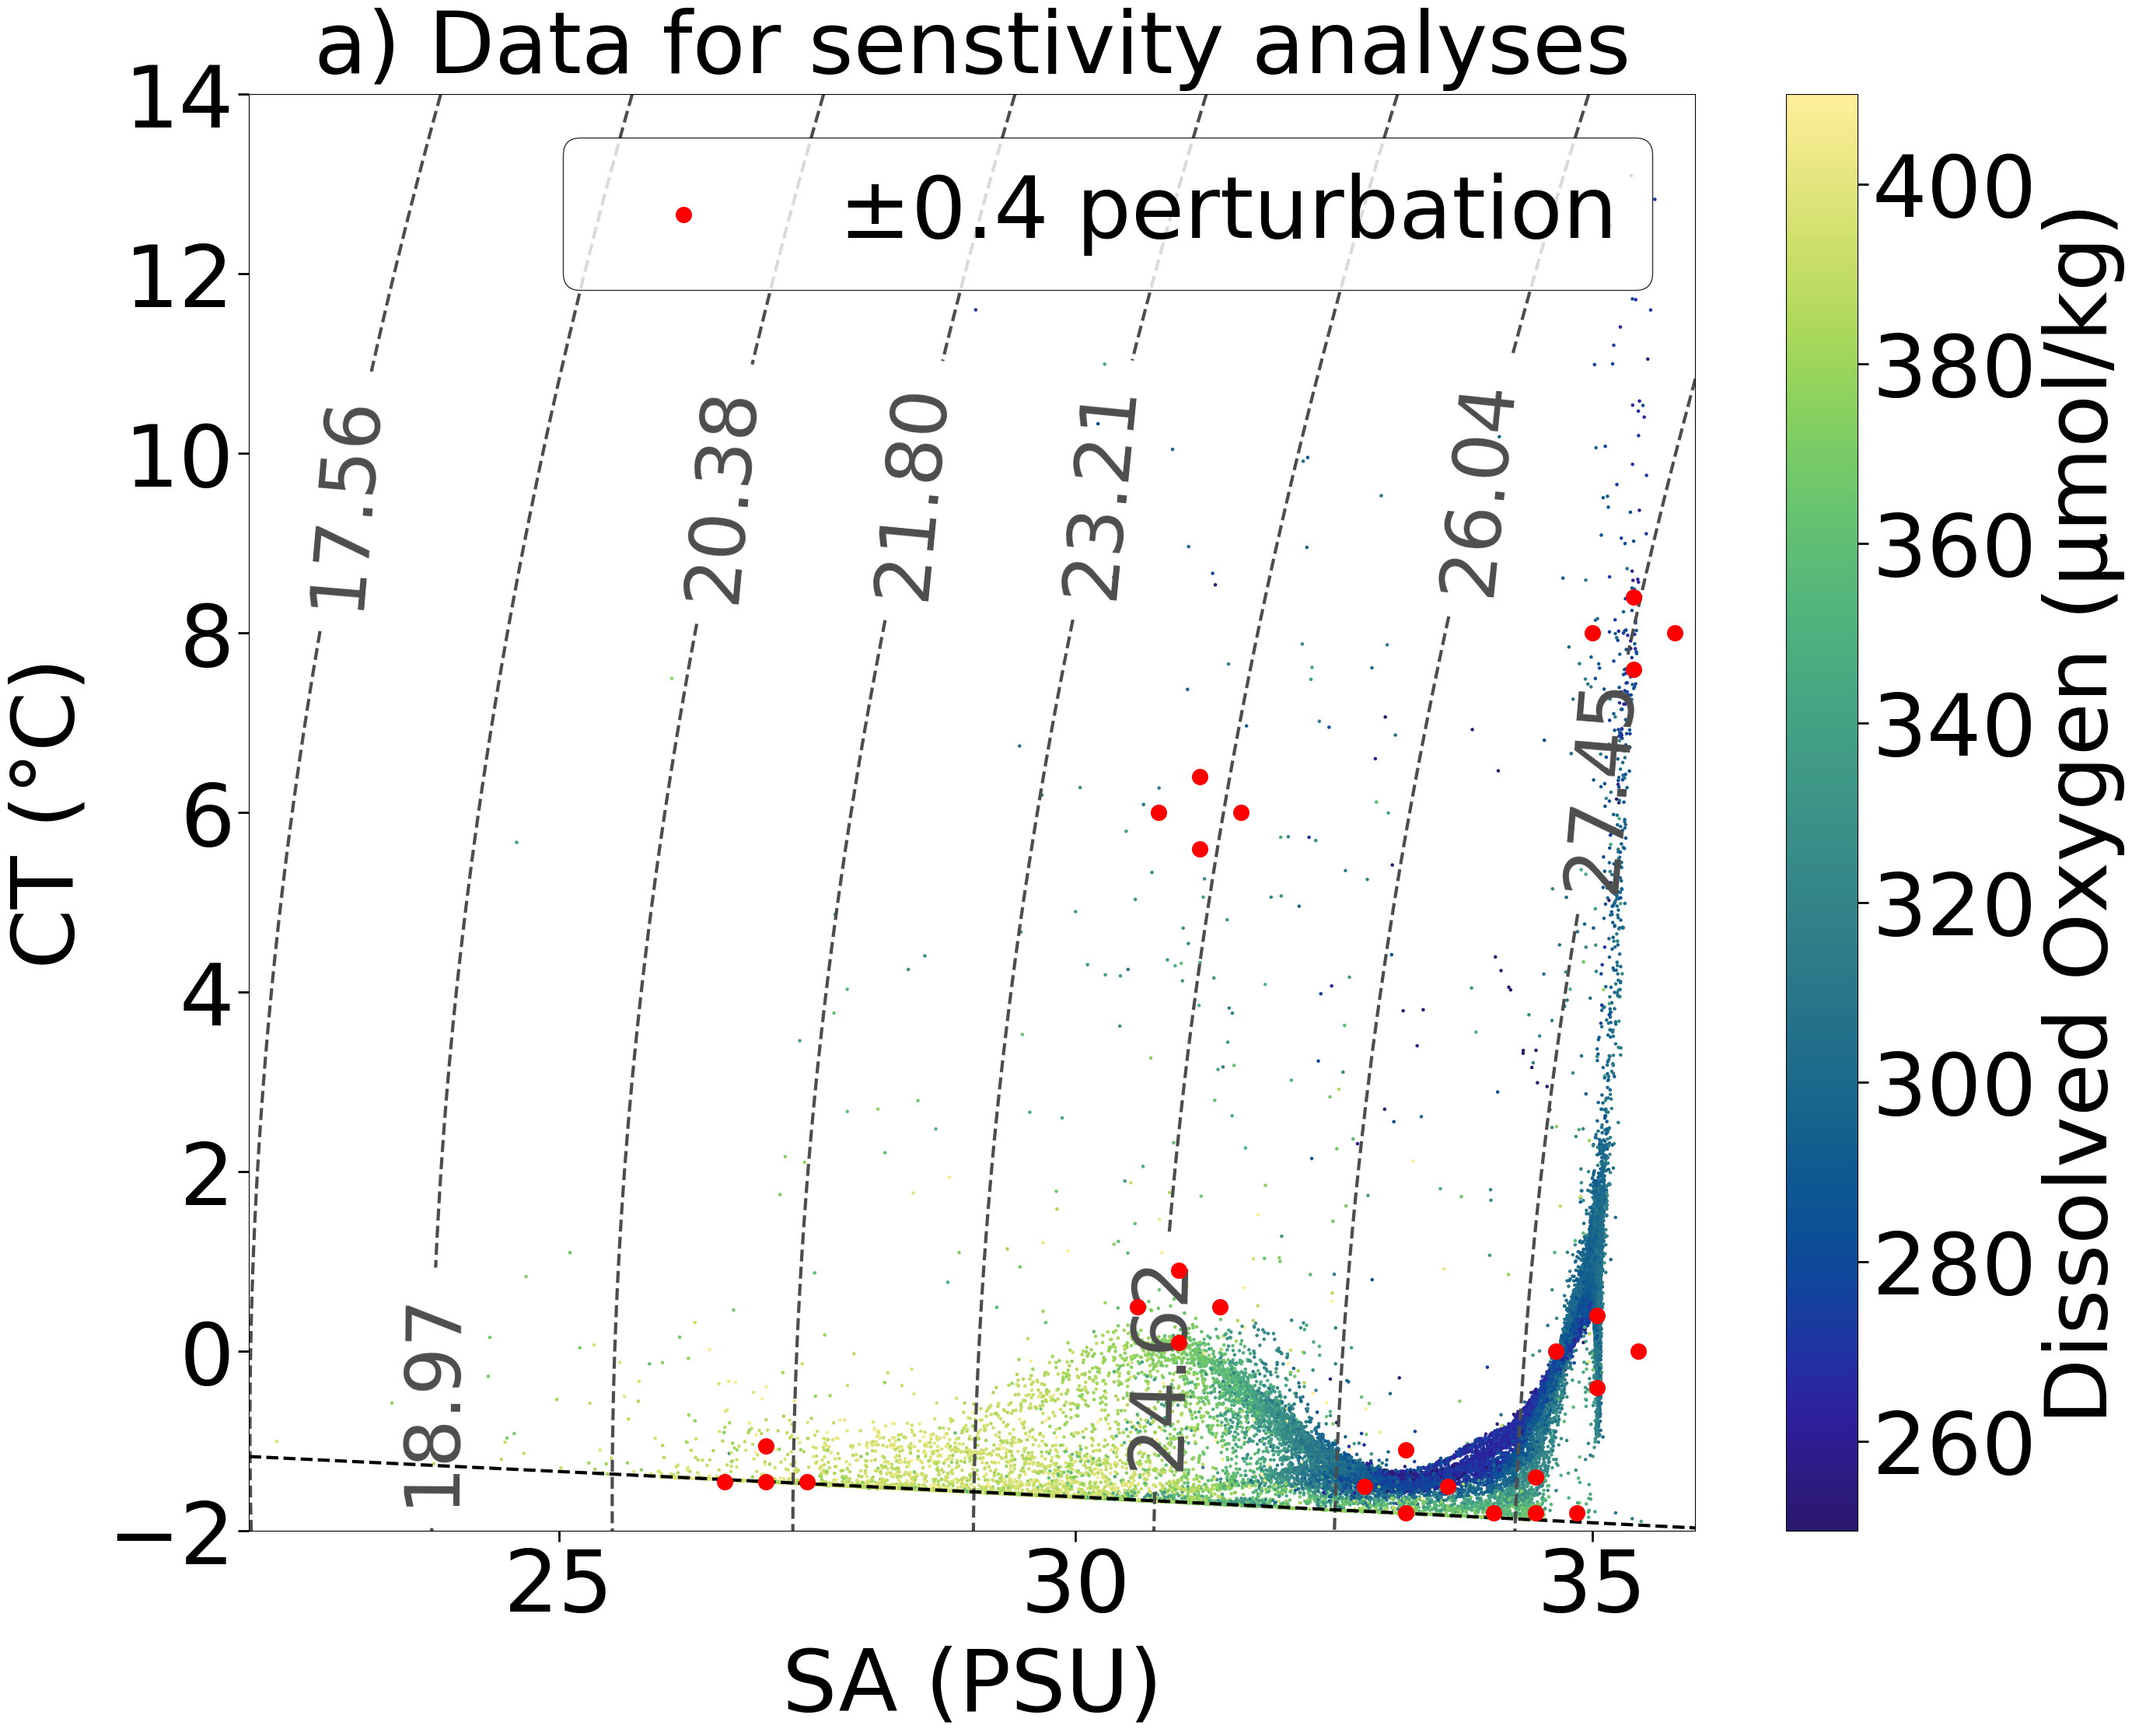

In [63]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.path as mpath
from matplotlib.colors import LogNorm
import seaborn as sn
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean.cm as cmo
import pandas as pd
import gsw
import matplotlib.patches as patches

def create_TS_bivariate_histogram(data, values):
    
    fig, ax = plt.subplots(1, 1, figsize=(30, 24))  # Bigger figure size


    # Scatter plot

    sc = ax.scatter(data['absolute_salinity'], data['conservative_temp'], c=data['oxygen'], s=5,cmap=cmo.haline, vmin=250, vmax=410)
    cbar = plt.colorbar(sc)
    # Add colorbar
    cbar.set_label('Dissolved Oxygen (\u00b5mol/kg)', fontsize=80)
    cbar.ax.tick_params(labelsize=80, width=2, length=10)

    # Sigma0 density contours
    SA, CT = np.meshgrid(np.linspace(22, 36, 400), np.linspace(-2, 14, 400))
    sigma0 = gsw.sigma0(SA, CT)
    levels = np.linspace(np.min(sigma0), np.max(sigma0), 10)
    contour = ax.contour(
        SA, CT, sigma0, levels=levels, 
        linestyles='--', colors='#4d4d4d', linewidths=3
    )
    ax.clabel(contour, inline=True, fontsize=70)

    # Add SWTs + perturbation boxes
    # Define SWTs
    """specific_points = [
        {'label': 'A', 'absolute_salinity': values['ASW_S'], 'conservative_temp': values['ASW_T'], 'water_mass': 'Arctic Surface Water'},     
        {'label': 'B', 'absolute_salinity': values['sPW_S'], 'conservative_temp': values['sPW_T'], 'water_mass': 'Alaskan Coastal Current Water'},     
        {'label': 'C', 'absolute_salinity': values['MsPW_S'], 'conservative_temp': values['MsPW_T'], 'water_mass': 'summer Pacific Water'},     
        {'label': 'D', 'absolute_salinity': values['wPW_S'], 'conservative_temp': values['wPW_T'], 'water_mass': 'winter Pacific Water'},     
        {'label': 'E', 'absolute_salinity': values['NCW_S'], 'conservative_temp': values['NCW_T'], 'water_mass': 'Norwegian Current Water'},       
        {'label': 'F', 'absolute_salinity': values['AW_S'], 'conservative_temp': values['AW_T'], 'water_mass': 'Moderated Atlantic Water'},     
        {'label': 'G', 'absolute_salinity': values['BW_S'], 'conservative_temp': values['BW_T'], 'water_mass': 'Brine-enriched Water'}      
    ]
    for point in specific_points:
        sa, ct = point['absolute_salinity'], point['conservative_temp']
        #ax.scatter(sa, ct, marker='s', color='cyan', s=2000, label=f"{point['label']} - {point['water_mass']}")
        #ax.text(sa, ct, point['label'], ha='center', va='center', color='black', fontsize=50)
        # Add perturbation box
        rect = patches.Rectangle((sa - 0.2, ct - 0.2), 0.2, 0.2,
                                 linewidth=4, edgecolor='red', facecolor='none')
        ax.add_patch(rect)"""

    # Plot actual perturbation points as red dots
    for i, pt in enumerate(perturbation_tests):
        if i == 0:  # only label the first point so it appears once in the legend
            ax.scatter(pt['SA'], pt['CT'], color='red', s=200, zorder=5, label='\u00B10.4 perturbation')
        else:
            ax.scatter(pt['SA'], pt['CT'], color='red', s=200, zorder=5)

    # Add legend
    ax.legend(loc='upper right', fontsize=80, edgecolor='black')

    # Freezing line
    CT_freezing = gsw.CT_freezing(np.linspace(22, 36, 400), 0, 0)
    ax.plot(
        np.linspace(22, 36, 400), CT_freezing, 
        linestyle='--', color='black', linewidth=3, label="Freezing Line"
    )

    # Labels and axis limits
    ax.set_xlabel('SA (PSU)', fontsize=80, labelpad=15)
    ax.set_ylabel('CT (\u00b0C)', fontsize=80, labelpad=15)
    ax.set_xlim([22, 36])
    ax.set_ylim([-2, 14])
    ax.tick_params(axis='both', which='major', labelsize=80, width=2, length=10)

    # Add title
    #ax.set_title('b) All data', fontsize=80, pad=20)
    ax.set_title('a) Data for senstivity analyses', fontsize=80, pad=20)
    # Colorbar
    #cbar = plt.colorbar(hist[3], ax=ax)
    #cbar.set_label('Number of T, S data points', fontsize=70)
    #cbar.ax.tick_params(labelsize=60, width=2, length=10)

    # Remove grid
    ax.grid(False)

    # Show plot
    plt.show()
    #fig.savefig('/Users/ko389/Documents/T_S_distribution', dpi=300, bbox_inches='tight', transparent=True)

create_TS_bivariate_histogram(df_sampled, values)

In [ ]:
create_TS_bivariate_histogram(df, values)

Run OMP X times altering DO weights. 

Sensitivity to long-term modification of SWTs




In [81]:
# Load data

import pandas as pd
import numpy as np
import xarray as xr

data_path = '/Users/ko389/Documents/GitHub/Arctic_water_masses/data_products/OMP_output_post_2010.nc'
wm_2010 = xr.open_dataset(data_path).to_dataframe()

data_path = '/Users/ko389/Documents/GitHub/Arctic_water_masses/data_products/OMP_output_DO_weighted_equally.nc'
wm_DO_weighted_equally = xr.open_dataset(data_path).to_dataframe()

data_path = '/Users/ko389/Documents/GitHub/Arctic_water_masses/data_products/OMP_output.nc'
wm= xr.open_dataset(data_path).to_dataframe()




In [78]:
wm

,conservative_temp,absolute_salinity,oxygen,latitude,longitude,depth,source,nprof,datetime,ASW,AW,MAW,sPW,sPWW,wPW,BSW
index,,,,,,,,,,,,,,,,
0,7.568,35.200,299.264,69.893,3.994,5.0,argo,11,2022-06-14 02:51:00,0.011023,0.941303,0.020382,0.010413,0.009902,0.004995,0.001982
1,7.529,35.199,298.703,69.870,3.930,15.0,argo,11,2022-06-12 14:06:00,0.010875,0.935555,0.026131,0.009580,0.011076,0.004311,0.002472
2,6.170,35.250,296.322,69.895,3.919,105.0,argo,11,2022-06-12 14:06:00,0.001219,0.791468,0.111507,0.001100,0.001215,0.001583,0.091910
3,6.138,35.252,295.827,69.870,4.025,115.0,argo,11,2022-06-12 14:06:00,0.004047,0.765444,0.220595,0.003808,0.003701,0.001768,0.000637
4,6.091,35.252,295.818,69.884,3.960,125.0,argo,11,2022-06-12 14:06:00,0.001147,0.779739,0.131823,0.001036,0.001156,0.001579,0.083520
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1179487,1.381,35.024,320.050,83.788,14.126,205.0,MOSAiC,118,2020-05-09 07:38:44,0.005254,0.169894,0.812281,0.004771,0.005202,0.001809,0.000789
1179488,1.393,35.025,320.000,83.788,14.126,255.0,MOSAiC,118,2020-05-09 07:38:44,0.005221,0.171399,0.811041,0.004793,0.005128,0.001883,0.000535
1179489,-1.860,34.480,380.370,83.788,14.126,45.0,MOSAiC,118,2020-05-09 07:38:44,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000


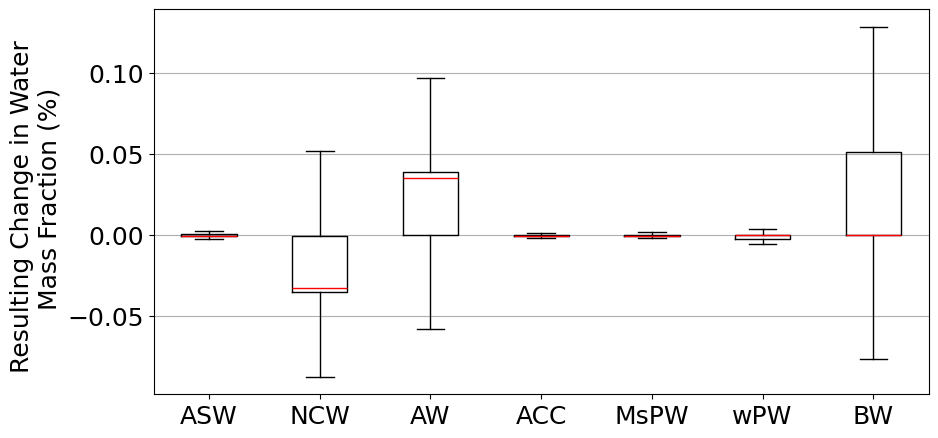

In [80]:
# Sensitivity to chosing summer or winter ASW

# Calculate and plot the difference in WM fractions
WM_diff = wm_2010[['ASW', 'AW', 'MAW', 'sPW', 'sPWW', 'wPW', 'BSW']] - wm[['ASW', 'AW', 'MAW', 'sPW', 'sPWW', 'wPW', 'BSW']]

# Plotting
plt.figure(figsize=(10, 5))  # Increase figure size

# Create box plot without outliers
boxplot = plt.boxplot(WM_diff, showfliers=False)

# Customize the plot with larger font sizes
#plt.title('OMP Sensitivity to DO Weighting', fontsize=22)  # Larger title
plt.ylabel('Resulting Change in Water \n Mass Fraction (%)', fontsize=18)
#plt.xlabel('Water Mass', fontsize=18)

# Define custom x-axis labels
custom_labels = ['ASW', 'NCW', 'AW', 'ACC', 'MsPW', 'wPW', 'BW']

# Set xticks with larger font size
plt.xticks(range(1, len(custom_labels) + 1), custom_labels, fontsize=18)#, rotation=45, ha='right')
plt.yticks(fontsize=18)  # Increase y-axis tick labels

# Add grid and style median lines
plt.grid(axis='y')
plt.setp(boxplot['medians'], color='red')

# Display the plot
plt.show()

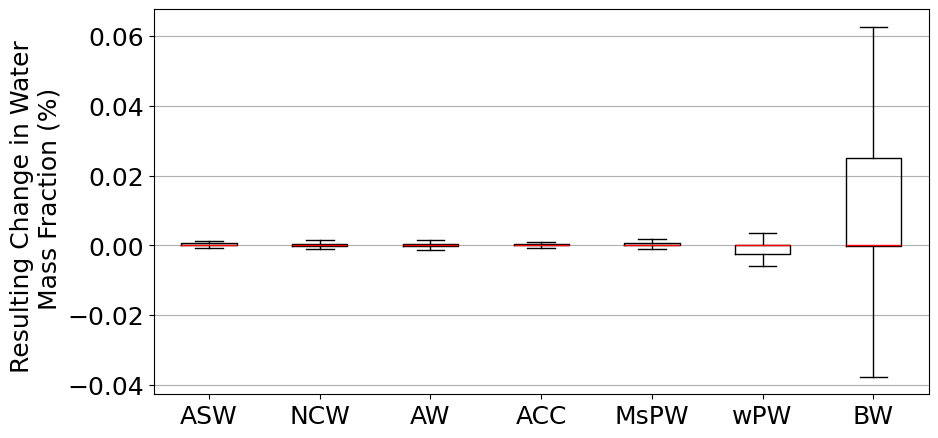

In [82]:
# Sensitivity to chosing summer or winter ASW

# Calculate and plot the difference in WM fractions
WM_diff = wm_DO_weighted_equally[['ASW', 'AW', 'MAW', 'sPW', 'sPWW', 'wPW', 'BSW']] - wm[['ASW', 'AW', 'MAW', 'sPW', 'sPWW', 'wPW', 'BSW']]

# Plotting
plt.figure(figsize=(10, 5))  # Increase figure size

# Create box plot without outliers
boxplot = plt.boxplot(WM_diff, showfliers=False)

# Customize the plot with larger font sizes
#plt.title('OMP Sensitivity to DO Weighting', fontsize=22)  # Larger title
plt.ylabel('Resulting Change in Water \n Mass Fraction (%)', fontsize=18)
#plt.xlabel('Water Mass', fontsize=18)

# Define custom x-axis labels
custom_labels = ['ASW', 'NCW', 'AW', 'ACC', 'MsPW', 'wPW', 'BW']

# Set xticks with larger font size
plt.xticks(range(1, len(custom_labels) + 1), custom_labels, fontsize=18)#, rotation=45, ha='right')
plt.yticks(fontsize=18)  # Increase y-axis tick labels

# Add grid and style median lines
plt.grid(axis='y')
plt.setp(boxplot['medians'], color='red')

# Display the plot
plt.show()

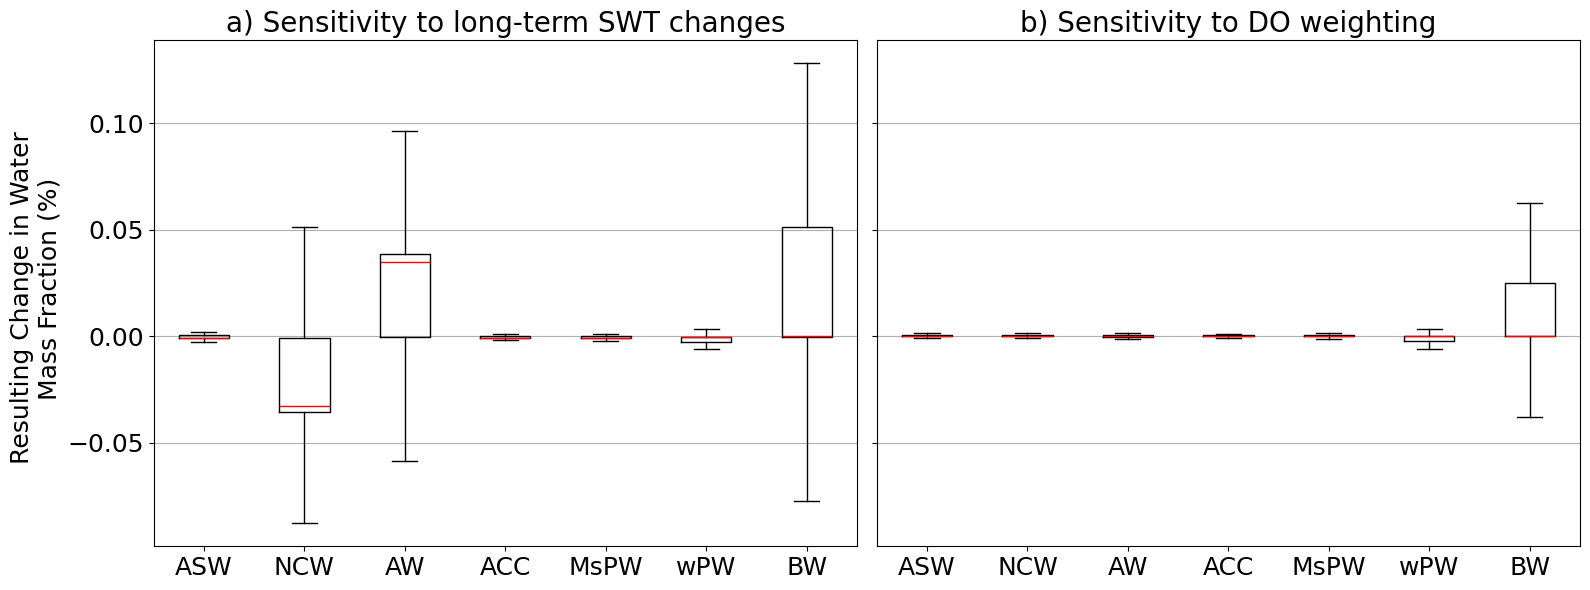

In [84]:
import matplotlib.pyplot as plt

# --- (a) Sensitivity to long-term SWT changes ---
WM_diff_a = wm_2010[['ASW', 'AW', 'MAW', 'sPW', 'sPWW', 'wPW', 'BSW']] - wm[['ASW', 'AW', 'MAW', 'sPW', 'sPWW', 'wPW', 'BSW']]

# --- (b) Sensitivity to DO weighting ---
WM_diff_b = wm_DO_weighted_equally[['ASW', 'AW', 'MAW', 'sPW', 'sPWW', 'wPW', 'BSW']] - wm[['ASW', 'AW', 'MAW', 'sPW', 'sPWW', 'wPW', 'BSW']]

# Custom labels
custom_labels = ['ASW', 'NCW', 'AW', 'ACC', 'MsPW', 'wPW', 'BW']

# Create 1 figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# --- Subplot a ---
boxplot_a = axes[0].boxplot(WM_diff_a, showfliers=False)
axes[0].set_ylabel('Resulting Change in Water \n Mass Fraction (%)', fontsize=18)
axes[0].set_xticks(range(1, len(custom_labels) + 1))
axes[0].set_xticklabels(custom_labels, fontsize=18)
axes[0].tick_params(axis='y', labelsize=18)
axes[0].grid(axis='y')
plt.setp(boxplot_a['medians'], color='red')
axes[0].set_title('a) Sensitivity to long-term SWT changes', fontsize=20)

# --- Subplot b ---
boxplot_b = axes[1].boxplot(WM_diff_b, showfliers=False)
axes[1].set_xticks(range(1, len(custom_labels) + 1))
axes[1].set_xticklabels(custom_labels, fontsize=18)
axes[1].tick_params(axis='y', labelsize=18)
axes[1].grid(axis='y')
plt.setp(boxplot_b['medians'], color='red')
axes[1].set_title('b) Sensitivity to DO weighting', fontsize=20)

plt.tight_layout()
plt.show()
